# Pitch Homography â€” Line Detection & Camera Calibration

**Goal:** Detect football pitch lines from broadcast footage and estimate a homography
to map player positions onto a 2D pitch template.

## Approach (Classical CV â€” no extra dependencies)
1. **Field segmentation** â€” HSV green mask to isolate the pitch
2. **White line detection** â€” Threshold for bright/low-saturation pixels within the field
3. **Hough line transform** â€” Detect straight lines from the white mask
4. **Line filtering & merging** â€” Cluster similar lines, remove noise
5. **Intersection detection** â€” Find where pitch lines meet (candidate keypoints)
6. **Pitch template** â€” Standard FIFA pitch with known keypoint coordinates
7. **Homography estimation** â€” Map image keypoints â†’ pitch template via `cv2.findHomography`

In [1]:
import sys
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, Circle
from tqdm import tqdm
import importlib

sys.path.insert(0, str(Path.cwd()))

import src.config, src.video_utils
importlib.reload(src.config)
importlib.reload(src.video_utils)

from src.config import Config
from src.video_utils import extract_clip, open_video, get_video_info, create_video_writer

print("Modules loaded.")

Modules loaded.


## 1. Extract & Sample Frames (20:00 â€“ 21:00)

In [ ]:
# Extract a 1-minute clip from SUTJESKA - MLADOST
SUT_MLA_VIDEO = Config.VIDEOS_DIR / "SUTJESKA - MLADOST 1.CFL 21.03.2026. CIJELA UTAKMICA.mp4"
CLIP_START_SEC = 20 * 60   # 20:00
CLIP_DURATION_SEC = 60     # 1 minute

clip_path = Config.VIDEOS_DIR / "homography_sut_mla_1min.mp4"

extract_clip(
    source=SUT_MLA_VIDEO,
    output=clip_path,
    start_sec=CLIP_START_SEC,
    duration_sec=CLIP_DURATION_SEC,
)

homography_test_1min.mp4: 1920x1080 @ 25.0fps, 1500 frames


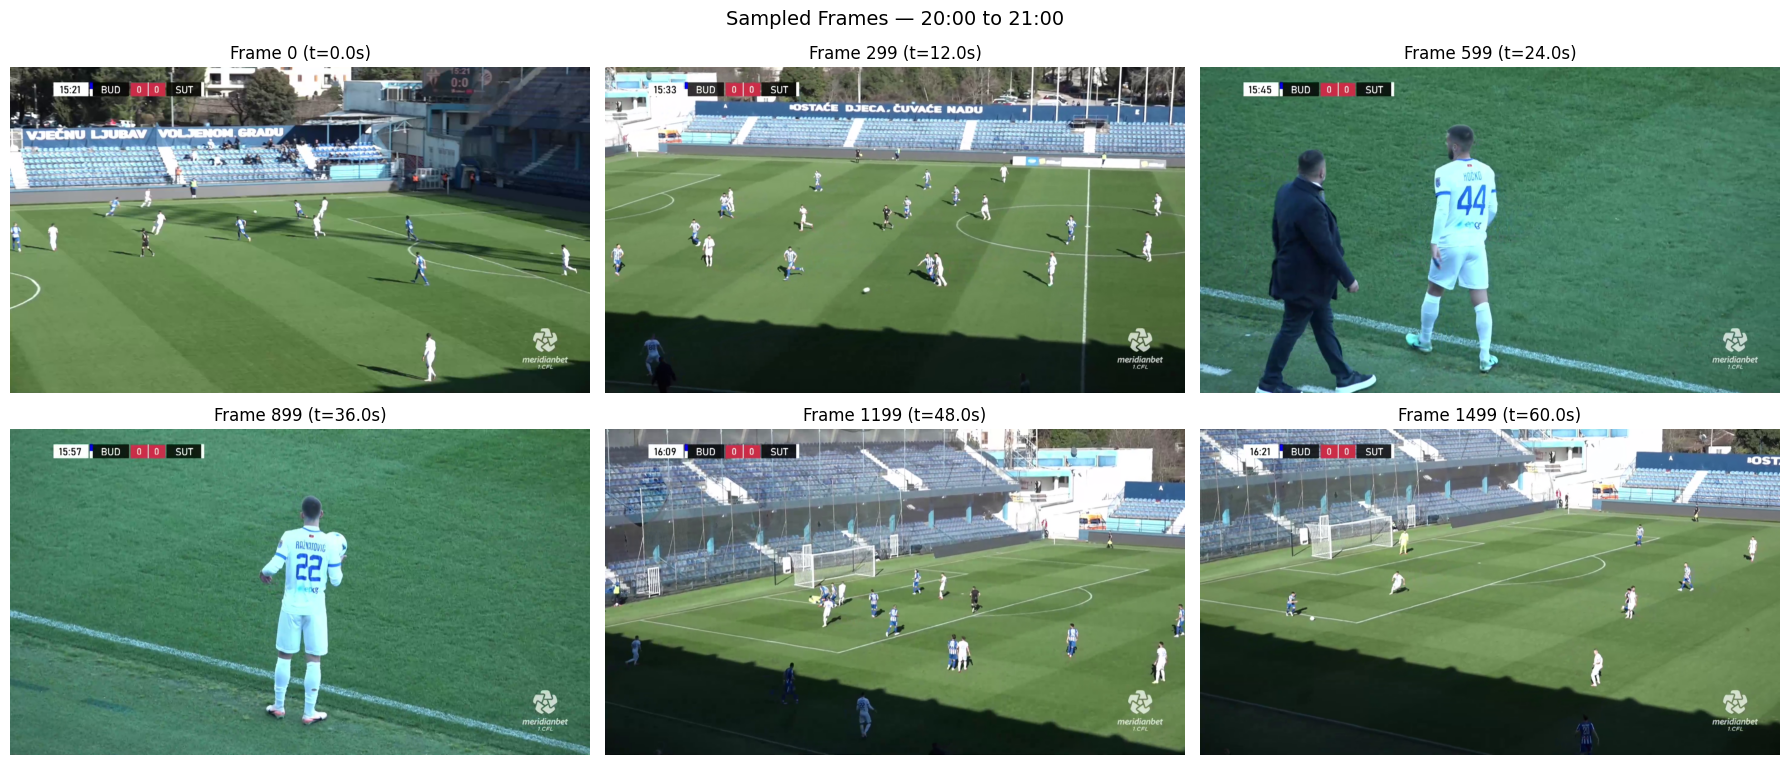

In [3]:
# Sample 6 evenly spaced frames for visualization
cap = open_video(clip_path)
info = get_video_info(cap)
print(f"{clip_path.name}: {info['width']}x{info['height']} @ {info['fps']:.1f}fps, {info['total_frames']} frames")

sample_indices = np.linspace(0, info['total_frames'] - 1, 6, dtype=int)
frames = []
for idx in sample_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    if ret:
        frames.append(frame)
cap.release()

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for i, (ax, frame) in enumerate(zip(axes.flat, frames)):
    ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    t = sample_indices[i] / info['fps']
    ax.set_title(f'Frame {sample_indices[i]} (t={t:.1f}s)')
    ax.axis('off')
plt.suptitle('Sampled Frames â€” 20:00 to 21:00', fontsize=14)
plt.tight_layout()
plt.show()

## 2. Field Segmentation (HSV Green Mask)

Isolate the green pitch area to exclude advertising boards, stands, and sky.

In [4]:
def detect_field_mask(frame, lower_green=None, upper_green=None):
    """
    Detect the green football field using HSV color segmentation.
    Returns a binary mask where 255 = field.
    """
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    if lower_green is None:
        lower_green = np.array([30, 25, 25])
    if upper_green is None:
        upper_green = np.array([90, 255, 255])

    mask = cv2.inRange(hsv, lower_green, upper_green)

    # Morphological cleanup: close holes, remove small noise
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (21, 21))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # Keep only the largest connected component (the pitch)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        mask = np.zeros_like(mask)
        cv2.drawContours(mask, [largest], -1, 255, cv2.FILLED)

    return mask

In [ ]:
# Visualize field masks for all sampled frames
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
field_masks = []

for i, (ax, frame) in enumerate(zip(axes.flat, frames)):
    mask = detect_field_mask(frame)
    field_masks.append(mask)

    # Overlay mask as green tint on original
    overlay = frame.copy()
    overlay[mask == 255] = (overlay[mask == 255] * 0.5 + np.array([0, 100, 0]) * 0.5).astype(np.uint8)
    overlay[mask == 0] = (overlay[mask == 0] * 0.3).astype(np.uint8)

    ax.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    coverage = mask.sum() / 255 / mask.size * 100
    ax.set_title(f'Frame {sample_indices[i]} â€” field {coverage:.0f}%')
    ax.axis('off')

plt.suptitle('Field Segmentation (HSV Green Mask)', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Pitch Line Detection

Within the field mask, detect white pitch markings using:
1. **Color threshold** â€” low saturation + high value = white
2. **Morphological cleanup** â€” remove small blobs (player jerseys), keep thin lines
3. **Hough Line Transform** â€” extract straight line segments

In [ ]:
def mask_broadcast_overlays(mask, frame_shape):
    """
    Zero-out regions where broadcast overlays typically appear:
    scoreboard (top-left), clock/logo (bottom-right corners).
    """
    h, w = frame_shape[:2]
    # Top strip — scoreboards, clocks (top 12%)
    mask[:int(h * 0.12), :] = 0
    # Bottom-right corner — broadcaster logo
    mask[int(h * 0.88):, int(w * 0.75):] = 0
    # Bottom-left corner (sometimes used too)
    mask[int(h * 0.88):, :int(w * 0.08)] = 0
    return mask


def detect_white_lines_mask(frame, field_mask):
    """
    Detect white pitch lines within the field area.
    Combines two complementary approaches:
      1) Color thresholding (bright, low-saturation pixels)
      2) Canny edge detection (local contrast — works in all lighting)
    """
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Erode field mask to exclude boundary artifacts
    eroded_field = cv2.erode(field_mask, np.ones((15, 15), np.uint8))
    eroded_field = mask_broadcast_overlays(eroded_field, frame.shape)

    # --- Approach 1: Color-based (bright + low-saturation) ---
    field_pixels_v = hsv[:, :, 2][eroded_field > 0]
    if len(field_pixels_v) == 0:
        return np.zeros(frame.shape[:2], dtype=np.uint8)

    field_median_v = np.median(field_pixels_v)
    field_std_v = np.std(field_pixels_v)

    val_min_color = max(int(field_median_v + 1.8 * field_std_v), 140)
    lower_white = np.array([0, 0, val_min_color])
    upper_white = np.array([180, 80, 255])
    color_mask = cv2.inRange(hsv, lower_white, upper_white)
    color_mask = cv2.bitwise_and(color_mask, eroded_field)

    # --- Approach 2: Canny edges within field, filtered by brightness ---
    # Apply CLAHE to enhance local contrast before edge detection
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)

    edges = cv2.Canny(enhanced, 50, 150)
    edges = cv2.bitwise_and(edges, eroded_field)

    # Only keep edge pixels that are brighter than the field median
    # (rejects dark edges like shadow boundaries)
    bright_enough = hsv[:, :, 2] > int(field_median_v + 0.5 * field_std_v)
    edge_mask = cv2.bitwise_and(edges, edges, mask=bright_enough.astype(np.uint8) * 255)

    # Dilate edges slightly to connect fragmented line boundaries
    edge_mask = cv2.dilate(edge_mask, np.ones((3, 3), np.uint8))

    # --- Combine both approaches ---
    line_mask = cv2.bitwise_or(color_mask, edge_mask)

    # Morphological open to remove small noise
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    line_mask = cv2.morphologyEx(line_mask, cv2.MORPH_OPEN, kernel)

    # Filter connected components — keep elongated shapes, reject blobs
    num_labels, labels, comp_stats, _ = cv2.connectedComponentsWithStats(
        line_mask, connectivity=8
    )
    filtered = np.zeros_like(line_mask)
    for lbl in range(1, num_labels):
        area = comp_stats[lbl, cv2.CC_STAT_AREA]
        cw = comp_stats[lbl, cv2.CC_STAT_WIDTH]
        ch = comp_stats[lbl, cv2.CC_STAT_HEIGHT]
        aspect = max(cw, ch) / (min(cw, ch) + 1e-5)
        fill_ratio = area / (cw * ch + 1e-5)

        if area < 15:
            continue  # noise

        # Reject blobby shapes: compact, well-filled, and large
        if aspect < 1.8 and fill_ratio > 0.35 and area > 400:
            continue

        filtered[labels == lbl] = 255

    return filtered


def detect_hough_lines(line_mask, min_length=80, max_gap=15, threshold=60):
    """
    Detect straight lines using Probabilistic Hough Transform.
    Returns Nx4 array of [x1, y1, x2, y2] line segments.
    """
    lines = cv2.HoughLinesP(
        line_mask,
        rho=1,
        theta=np.pi / 180,
        threshold=threshold,
        minLineLength=min_length,
        maxLineGap=max_gap,
    )
    if lines is None:
        return np.array([])
    return lines.reshape(-1, 4)


def validate_line_on_mask(seg, line_mask, min_support=0.35):
    """
    Check that enough pixels along a line segment actually lie on the white mask.
    Returns True if the line has sufficient support.
    """
    x1, y1, x2, y2 = seg
    length = int(np.sqrt((x2 - x1)**2 + (y2 - y1)**2))
    if length == 0:
        return False
    num_samples = max(length, 20)
    xs = np.linspace(x1, x2, num_samples).astype(int)
    ys = np.linspace(y1, y2, num_samples).astype(int)
    h, w = line_mask.shape[:2]
    valid = (xs >= 0) & (xs < w) & (ys >= 0) & (ys < h)
    xs, ys = xs[valid], ys[valid]
    if len(xs) == 0:
        return False
    support = np.mean(line_mask[ys, xs] > 0)
    return support >= min_support

In [ ]:
# Visualize: original â†’ white mask â†’ Hough lines (for 3 frames)
vis_indices = [0, 2, 4]  # pick 3 spread-out frames

fig, axes = plt.subplots(len(vis_indices), 3, figsize=(18, 5 * len(vis_indices)))

for row, fi in enumerate(vis_indices):
    frame = frames[fi]
    mask = field_masks[fi]

    # White line mask
    line_mask = detect_white_lines_mask(frame, mask)

    # Hough lines
    raw_lines = detect_hough_lines(line_mask)

    # Draw lines on frame
    line_overlay = frame.copy()
    for x1, y1, x2, y2 in raw_lines:
        cv2.line(line_overlay, (x1, y1), (x2, y2), (0, 0, 255), 2)

    # Col 0: original
    axes[row, 0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title(f'Frame {sample_indices[fi]}' if row == 0 else '')
    axes[row, 0].axis('off')

    # Col 1: white line mask
    axes[row, 1].imshow(line_mask, cmap='gray')
    axes[row, 1].set_title('White Line Mask' if row == 0 else '')
    axes[row, 1].axis('off')

    # Col 2: Hough lines
    axes[row, 2].imshow(cv2.cvtColor(line_overlay, cv2.COLOR_BGR2RGB))
    axes[row, 2].set_title(f'Hough Lines ({len(raw_lines)})' if row == 0 else f'({len(raw_lines)} lines)')
    axes[row, 2].axis('off')

plt.suptitle('Pitch Line Detection Pipeline', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Line Filtering & Merging

The raw Hough output contains many duplicate/overlapping segments for the same physical line.
We merge nearby parallel segments into single representative lines.

In [ ]:
def merge_lines(lines, angle_thresh=8, dist_thresh=25, line_mask=None):
    """
    Merge line segments that belong to the same physical pitch line.
    Groups by angle similarity + perpendicular distance between midpoints.
    Optionally validates each merged line against the white line mask.
    Returns list of representative [x1, y1, x2, y2] segments.
    """
    if len(lines) == 0:
        return []

    # Optionally pre-filter: only keep lines with real white-pixel support
    if line_mask is not None:
        lines = [seg for seg in lines if validate_line_on_mask(seg, line_mask)]
    if len(lines) == 0:
        return []

    # Compute angle, midpoint, and length for each line
    params = []
    for x1, y1, x2, y2 in lines:
        angle = np.degrees(np.arctan2(y2 - y1, x2 - x1)) % 180
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        params.append((angle, mx, my, length, [x1, y1, x2, y2]))

    # Sort by length (longest first — better representatives)
    params.sort(key=lambda p: -p[3])

    used = [False] * len(params)
    merged = []

    for i, (ai, mxi, myi, li, seg_i) in enumerate(params):
        if used[i]:
            continue
        used[i] = True
        cluster_segs = [seg_i]

        for j in range(i + 1, len(params)):
            if used[j]:
                continue
            aj, mxj, myj, lj, seg_j = params[j]

            # Angle similarity
            angle_diff = min(abs(ai - aj), 180 - abs(ai - aj))
            if angle_diff > angle_thresh:
                continue

            # Perpendicular distance between midpoints
            rad = np.radians(ai)
            dx, dy = mxj - mxi, myj - myi
            perp_dist = abs(dx * np.sin(rad) - dy * np.cos(rad))

            if perp_dist < dist_thresh:
                cluster_segs.append(seg_j)
                used[j] = True

        # Represent the cluster: take all endpoints, fit a line through them,
        # and use the extreme projections as the merged segment endpoints
        all_pts = []
        for s in cluster_segs:
            all_pts.append([s[0], s[1]])
            all_pts.append([s[2], s[3]])
        all_pts = np.array(all_pts, dtype=np.float32)

        # Direction from longest segment (already first)
        dx = seg_i[2] - seg_i[0]
        dy = seg_i[3] - seg_i[1]
        norm = np.sqrt(dx**2 + dy**2) + 1e-8
        direction = np.array([dx / norm, dy / norm])

        # Project all points onto the direction vector
        center = all_pts.mean(axis=0)
        projections = (all_pts - center) @ direction
        t_min, t_max = projections.min(), projections.max()

        p1 = center + t_min * direction
        p2 = center + t_max * direction
        candidate = [int(p1[0]), int(p1[1]), int(p2[0]), int(p2[1])]

        # Post-merge validation: confirm the merged line still has mask support
        if line_mask is not None and not validate_line_on_mask(candidate, line_mask, min_support=0.25):
            continue

        merged.append(candidate)

    return merged

In [ ]:
# Compare raw vs merged lines on all sampled frames
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

merged_lines_per_frame = []

for i, (ax, frame) in enumerate(zip(axes.flat, frames)):
    mask = field_masks[i]
    line_mask = detect_white_lines_mask(frame, mask)
    raw = detect_hough_lines(line_mask)
    merged = merge_lines(raw, line_mask=line_mask)
    merged_lines_per_frame.append(merged)

    overlay = frame.copy()
    # Draw merged lines (thick green)
    for x1, y1, x2, y2 in merged:
        cv2.line(overlay, (x1, y1), (x2, y2), (0, 255, 0), 3)

    ax.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Frame {sample_indices[i]}: {len(raw)} raw → {len(merged)} merged')
    ax.axis('off')

plt.suptitle('Merged Pitch Lines', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Line Intersection Detection (Candidate Keypoints)

Find where merged lines intersect â€” these are candidate pitch keypoints
(penalty area corners, halfway line intersections, etc.).

In [ ]:
def line_intersection(seg1, seg2):
    """Find intersection of two infinite lines through seg1 and seg2."""
    x1, y1, x2, y2 = seg1
    x3, y3, x4, y4 = seg2

    denom = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
    if abs(denom) < 1e-10:
        return None  # parallel or coincident

    t = ((x1 - x3) * (y3 - y4) - (y1 - y3) * (x3 - x4)) / denom
    px = x1 + t * (x2 - x1)
    py = y1 + t * (y2 - y1)
    return (px, py)


def find_intersections(lines, frame_shape, min_angle_deg=20):
    """
    Find intersections between merged lines.
    Only keeps intersections within the frame and at reasonable angles.
    """
    h, w = frame_shape[:2]
    margin = 50
    intersections = []

    for i in range(len(lines)):
        for j in range(i + 1, len(lines)):
            # Check angle difference (skip near-parallel lines)
            a1 = np.arctan2(lines[i][3] - lines[i][1], lines[i][2] - lines[i][0])
            a2 = np.arctan2(lines[j][3] - lines[j][1], lines[j][2] - lines[j][0])
            angle_diff = abs(a1 - a2)
            angle_diff = min(angle_diff, np.pi - angle_diff)

            if angle_diff < np.radians(min_angle_deg):
                continue

            pt = line_intersection(lines[i], lines[j])
            if pt is None:
                continue

            x, y = pt
            if -margin <= x <= w + margin and -margin <= y <= h + margin:
                intersections.append((int(x), int(y)))

    return intersections


def cluster_intersections(points, radius=25):
    """Merge nearby intersection points into single keypoints."""
    if not points:
        return []

    pts = np.array(points, dtype=np.float32)
    used = [False] * len(pts)
    clustered = []

    for i in range(len(pts)):
        if used[i]:
            continue
        cluster = [pts[i]]
        used[i] = True
        for j in range(i + 1, len(pts)):
            if used[j]:
                continue
            if np.linalg.norm(pts[i] - pts[j]) < radius:
                cluster.append(pts[j])
                used[j] = True
        clustered.append(np.mean(cluster, axis=0).astype(int).tolist())

    return clustered

In [ ]:
# Visualize intersections on all sampled frames
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

all_frame_keypoints = []

for i, (ax, frame) in enumerate(zip(axes.flat, frames)):
    merged = merged_lines_per_frame[i]
    raw_ints = find_intersections(merged, frame.shape)
    keypoints = cluster_intersections(raw_ints)
    all_frame_keypoints.append(keypoints)

    overlay = frame.copy()
    # Draw lines
    for x1, y1, x2, y2 in merged:
        cv2.line(overlay, (x1, y1), (x2, y2), (0, 255, 0), 2)
    # Draw keypoints
    for idx, (kx, ky) in enumerate(keypoints):
        cv2.circle(overlay, (kx, ky), 8, (0, 0, 255), -1)
        cv2.circle(overlay, (kx, ky), 10, (255, 255, 255), 2)
        cv2.putText(overlay, str(idx), (kx + 12, ky - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    ax.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    ax.set_title(f'{len(merged)} lines, {len(keypoints)} keypoints')
    ax.axis('off')

plt.suptitle('Detected Lines & Intersection Keypoints', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Ellipse Detection (Center Circle / Penalty Arcs)

The center circle and penalty arcs appear as **ellipses** under perspective.
We fit ellipses to contours in the white line mask using `cv2.fitEllipse`.

In [ ]:
def detect_ellipses(line_mask, field_mask=None, min_arc_length=60, min_support=0.15):
    """
    Detect elliptical arcs (center circle, penalty arcs) seen under perspective.
    Handles partial / semi-ellipses by only validating the portion visible
    within the field mask.
    Returns list of ((cx, cy), (major, minor), angle) tuples (cv2.fitEllipse format).
    """
    h, w = line_mask.shape[:2]

    # Light blur to connect nearby arc fragments
    blurred = cv2.GaussianBlur(line_mask, (5, 5), 1)
    _, binary = cv2.threshold(blurred, 80, 255, cv2.THRESH_BINARY)

    # Dilate to bridge small gaps in arc segments
    dilated = cv2.dilate(binary, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9)))

    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    ellipses = []
    for cnt in contours:
        if len(cnt) < 5:
            continue

        arc_len = cv2.arcLength(cnt, closed=False)
        if arc_len < min_arc_length:
            continue

        # Check curvature — reject straight-ish contours
        hull = cv2.convexHull(cnt)
        hull_len = cv2.arcLength(hull, closed=True)
        if hull_len > 0:
            curvature = arc_len / hull_len
            # Straight lines have curvature ~1.0, arcs are higher
            if curvature < 0.6:
                continue

        ellipse = cv2.fitEllipse(cnt)
        (cx, cy), (axis_min, axis_max), angle = ellipse

        # Size filters
        if axis_max < 40 or axis_max > 600:
            continue
        if axis_min < 15:
            continue

        # Reject tiny near-circular blobs (player heads)
        if axis_max < 60 and axis_min / axis_max > 0.7:
            continue

        # Center must be on or near the frame
        margin = axis_max
        if cx < -margin or cx > w + margin or cy < -margin or cy > h + margin:
            continue

        # Validate: sample the ellipse arc, but only check support on
        # points that are in-frame AND on the field (handles semi-ellipses)
        angles_arr = np.linspace(0, 2 * np.pi, 90)
        a, b = axis_max / 2, axis_min / 2
        rad = np.radians(angle)
        cos_a, sin_a = np.cos(rad), np.sin(rad)
        ex = cx + a * np.cos(angles_arr) * cos_a - b * np.sin(angles_arr) * sin_a
        ey = cy + a * np.cos(angles_arr) * sin_a + b * np.sin(angles_arr) * cos_a
        ex, ey = ex.astype(int), ey.astype(int)

        in_bounds = (ex >= 0) & (ex < w) & (ey >= 0) & (ey < h)
        if field_mask is not None:
            on_field = np.zeros_like(in_bounds)
            on_field[in_bounds] = field_mask[ey[in_bounds], ex[in_bounds]] > 0
            valid = in_bounds & on_field
        else:
            valid = in_bounds

        ex_v, ey_v = ex[valid], ey[valid]
        if len(ex_v) < 8:
            continue

        support = np.mean(line_mask[ey_v, ex_v] > 0)
        if support < min_support:
            continue

        ellipses.append(ellipse)

    # Deduplicate overlapping ellipses
    if len(ellipses) <= 1:
        return ellipses

    kept = []
    used = [False] * len(ellipses)
    for i in range(len(ellipses)):
        if used[i]:
            continue
        used[i] = True
        best = ellipses[i]
        for j in range(i + 1, len(ellipses)):
            if used[j]:
                continue
            (cx1, cy1), (a1, _), _ = best
            (cx2, cy2), (a2, _), _ = ellipses[j]
            dist = np.sqrt((cx1 - cx2)**2 + (cy1 - cy2)**2)
            size_ratio = min(a1, a2) / (max(a1, a2) + 1e-5)
            if dist < max(a1, a2) * 0.5 and size_ratio > 0.5:
                used[j] = True
                if ellipses[j][1][1] > best[1][1]:
                    best = ellipses[j]
        kept.append(best)

    return kept

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for i, (ax, frame) in enumerate(zip(axes.flat, frames)):
    mask = field_masks[i]
    line_mask = detect_white_lines_mask(frame, mask)
    ellipses = detect_ellipses(line_mask, field_mask=mask)

    overlay = frame.copy()
    # Draw merged lines
    for x1, y1, x2, y2 in merged_lines_per_frame[i]:
        cv2.line(overlay, (x1, y1), (x2, y2), (0, 255, 0), 2)
    # Draw ellipses
    for ell in ellipses:
        cv2.ellipse(overlay, ell, (255, 0, 255), 3)

    ax.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    ax.set_title(f'{len(ellipses)} ellipse(s) detected')
    ax.axis('off')

plt.suptitle('Ellipse Detection (Center Circle / Penalty Arcs)', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Standard Pitch Template

A FIFA-standard football pitch (105m x 68m) with all key landmarks.
We'll use this as the **target** coordinate system for homography.

In [ ]:
# FIFA pitch dimensions (meters)
PITCH_L = 105.0     # length
PITCH_W = 68.0      # width
PA_L = 16.5         # penalty area depth
PA_W = 40.32        # penalty area width
GA_L = 5.5          # goal area depth
GA_W = 18.32        # goal area width
CR = 9.15           # center circle radius
PS = 11.0           # penalty spot distance from goal line

# Named keypoints (x=along length, y=along width, origin at bottom-left)
PITCH_KEYPOINTS = {
    # Corners
    'BL': (0, 0),
    'BR': (PITCH_L, 0),
    'TL': (0, PITCH_W),
    'TR': (PITCH_L, PITCH_W),

    # Center line
    'CB': (PITCH_L/2, 0),
    'CT': (PITCH_L/2, PITCH_W),
    'CC': (PITCH_L/2, PITCH_W/2),

    # Left penalty area
    'LPA_B': (PA_L, (PITCH_W - PA_W) / 2),
    'LPA_T': (PA_L, (PITCH_W + PA_W) / 2),
    'LPS': (PS, PITCH_W / 2),

    # Right penalty area
    'RPA_B': (PITCH_L - PA_L, (PITCH_W - PA_W) / 2),
    'RPA_T': (PITCH_L - PA_L, (PITCH_W + PA_W) / 2),
    'RPS': (PITCH_L - PS, PITCH_W / 2),

    # Left goal area
    'LGA_B': (GA_L, (PITCH_W - GA_W) / 2),
    'LGA_T': (GA_L, (PITCH_W + GA_W) / 2),

    # Right goal area
    'RGA_B': (PITCH_L - GA_L, (PITCH_W - GA_W) / 2),
    'RGA_T': (PITCH_L - GA_L, (PITCH_W + GA_W) / 2),

    # Penalty area + goal line intersections
    'L_PA_GL_B': (0, (PITCH_W - PA_W) / 2),
    'L_PA_GL_T': (0, (PITCH_W + PA_W) / 2),
    'R_PA_GL_B': (PITCH_L, (PITCH_W - PA_W) / 2),
    'R_PA_GL_T': (PITCH_L, (PITCH_W + PA_W) / 2),

    # Center circle intersections with halfway line
    'CC_B': (PITCH_L/2, PITCH_W/2 - CR),
    'CC_T': (PITCH_L/2, PITCH_W/2 + CR),
}

print(f"Pitch template: {PITCH_L}m x {PITCH_W}m")
print(f"{len(PITCH_KEYPOINTS)} named keypoints")

In [ ]:
def draw_pitch_template(ax=None, figsize=(12, 8)):
    """Draw a 2D football pitch template with all markings."""
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=figsize)

    ax.set_xlim(-5, PITCH_L + 5)
    ax.set_ylim(-5, PITCH_W + 5)
    ax.set_aspect('equal')
    ax.set_facecolor('#2d8a4e')

    line_color = 'white'
    lw = 2

    # Pitch outline
    ax.plot([0, PITCH_L, PITCH_L, 0, 0],
            [0, 0, PITCH_W, PITCH_W, 0], color=line_color, lw=lw)

    # Center line
    ax.plot([PITCH_L/2, PITCH_L/2], [0, PITCH_W], color=line_color, lw=lw)

    # Center circle
    center_circle = plt.Circle((PITCH_L/2, PITCH_W/2), CR,
                                fill=False, color=line_color, lw=lw)
    ax.add_patch(center_circle)
    ax.plot(PITCH_L/2, PITCH_W/2, 'o', color=line_color, markersize=4)

    # Left penalty area
    pa_b = (PITCH_W - PA_W) / 2
    pa_t = (PITCH_W + PA_W) / 2
    ax.plot([0, PA_L, PA_L, 0], [pa_b, pa_b, pa_t, pa_t], color=line_color, lw=lw)

    # Right penalty area
    ax.plot([PITCH_L, PITCH_L - PA_L, PITCH_L - PA_L, PITCH_L],
            [pa_b, pa_b, pa_t, pa_t], color=line_color, lw=lw)

    # Left goal area
    ga_b = (PITCH_W - GA_W) / 2
    ga_t = (PITCH_W + GA_W) / 2
    ax.plot([0, GA_L, GA_L, 0], [ga_b, ga_b, ga_t, ga_t], color=line_color, lw=lw)

    # Right goal area
    ax.plot([PITCH_L, PITCH_L - GA_L, PITCH_L - GA_L, PITCH_L],
            [ga_b, ga_b, ga_t, ga_t], color=line_color, lw=lw)

    # Penalty spots
    ax.plot(PS, PITCH_W/2, 'o', color=line_color, markersize=4)
    ax.plot(PITCH_L - PS, PITCH_W/2, 'o', color=line_color, markersize=4)

    # Penalty arcs (the part outside the penalty area)
    left_arc = Arc((PS, PITCH_W/2), 2*CR, 2*CR,
                    angle=0, theta1=-53, theta2=53,
                    color=line_color, lw=lw)
    right_arc = Arc((PITCH_L - PS, PITCH_W/2), 2*CR, 2*CR,
                     angle=0, theta1=127, theta2=233,
                     color=line_color, lw=lw)
    ax.add_patch(left_arc)
    ax.add_patch(right_arc)

    # Corner arcs
    for cx, cy in [(0, 0), (0, PITCH_W), (PITCH_L, 0), (PITCH_L, PITCH_W)]:
        t1 = 0 if cy == 0 else 270
        t2 = t1 + 90
        if cx == PITCH_L:
            t1, t2 = t1 + 90, t2 + 90
        corner = Arc((cx, cy), 2, 2, angle=0, theta1=t1, theta2=t2,
                      color=line_color, lw=lw)
        ax.add_patch(corner)

    # Label keypoints
    for name, (kx, ky) in PITCH_KEYPOINTS.items():
        ax.plot(kx, ky, 's', color='red', markersize=5, zorder=5)
        ax.annotate(name, (kx, ky), fontsize=6, color='yellow',
                    ha='center', va='bottom', xytext=(0, 4),
                    textcoords='offset points')

    ax.set_title(f'Pitch Template â€” {PITCH_L}m x {PITCH_W}m ({len(PITCH_KEYPOINTS)} keypoints)')
    ax.set_xlabel('Length (m)')
    ax.set_ylabel('Width (m)')
    return ax


draw_pitch_template()
plt.tight_layout()
plt.show()

## 8. Homography Estimation

To compute a homography we need **at least 4 matched point pairs**:
image pixel coordinates â†” pitch template coordinates.

Two approaches:
- **Manual**: Click/identify keypoints by visual inspection (reliable baseline)
- **Automatic**: Match detected intersections to template keypoints (harder, error-prone)

Below we try the **manual approach** on one frame to establish a baseline,
then visualize the resulting projection.

In [ ]:
# Pick a good frame with clear line visibility
# (Examine the detected keypoints above and choose one with visible landmarks)
BEST_FRAME_IDX = 0  # adjust based on which frame shows the most pitch lines
ref_frame = frames[BEST_FRAME_IDX]

# Show the frame with detected keypoints labeled for reference
fig, ax = plt.subplots(figsize=(16, 9))
overlay = ref_frame.copy()
for x1, y1, x2, y2 in merged_lines_per_frame[BEST_FRAME_IDX]:
    cv2.line(overlay, (x1, y1), (x2, y2), (0, 255, 0), 2)
for idx, (kx, ky) in enumerate(all_frame_keypoints[BEST_FRAME_IDX]):
    cv2.circle(overlay, (kx, ky), 8, (0, 0, 255), -1)
    cv2.circle(overlay, (kx, ky), 10, (255, 255, 255), 2)
    cv2.putText(overlay, str(idx), (kx + 12, ky - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

ax.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
ax.set_title(f'Reference frame â€” identify which keypoints correspond to pitch landmarks\n'
             f'Keypoint indices: 0â€“{len(all_frame_keypoints[BEST_FRAME_IDX])-1}')
ax.axis('off')
plt.tight_layout()
plt.show()

print("\nDetected keypoint coordinates (pixel):")
for idx, (kx, ky) in enumerate(all_frame_keypoints[BEST_FRAME_IDX]):
    print(f"  [{idx}] ({kx}, {ky})")

In [ ]:
# â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# MANUAL KEYPOINT MATCHING
#
# Look at the reference frame above and identify which detected
# keypoints (by index) correspond to which pitch template points.
#
# Example: if keypoint 3 in the image is the top-left corner of
# the right penalty area, you'd write:
#   (3, 'RPA_T')   â†’  image_pts[3] â†” PITCH_KEYPOINTS['RPA_T']
#
# You need at least 4 matches. More = better (RANSAC handles outliers).
# â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

# TODO: Fill in matches after examining the reference frame above.
# Format: list of (keypoint_index, pitch_keypoint_name)
MANUAL_MATCHES = [
    # (0, 'RPA_T'),
    # (1, 'RPA_B'),
    # (2, 'CT'),
    # (3, 'CB'),
]

if len(MANUAL_MATCHES) >= 4:
    image_pts = np.array(
        [all_frame_keypoints[BEST_FRAME_IDX][i] for i, _ in MANUAL_MATCHES],
        dtype=np.float32
    )
    pitch_pts = np.array(
        [PITCH_KEYPOINTS[name] for _, name in MANUAL_MATCHES],
        dtype=np.float32
    )

    H, status = cv2.findHomography(image_pts, pitch_pts, cv2.RANSAC, 5.0)
    inliers = status.sum()
    print(f"Homography computed: {inliers}/{len(MANUAL_MATCHES)} inliers")
    print(f"\nH = \n{H}")
else:
    H = None
    print(f"Need at least 4 manual matches (currently {len(MANUAL_MATCHES)}).")
    print("Fill in MANUAL_MATCHES above after examining the reference frame.")

In [ ]:
# Visualize the homography projection (if computed)
if H is not None:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Left: original frame with matched keypoints highlighted
    overlay = ref_frame.copy()
    for (ki, name), (sx, sy) in zip(MANUAL_MATCHES, image_pts):
        cv2.circle(overlay, (int(sx), int(sy)), 10, (0, 255, 255), 3)
        cv2.putText(overlay, name, (int(sx) + 15, int(sy)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
    axes[0].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Matched Keypoints')
    axes[0].axis('off')

    # Right: pitch template with projected keypoints
    ax = draw_pitch_template(ax=axes[1])

    # Project some test points (e.g., all detected keypoints)
    all_kps = np.array(all_frame_keypoints[BEST_FRAME_IDX], dtype=np.float32)
    if len(all_kps) > 0:
        projected = cv2.perspectiveTransform(
            all_kps.reshape(-1, 1, 2), H
        ).reshape(-1, 2)

        for (px, py) in projected:
            if -10 <= px <= PITCH_L + 10 and -10 <= py <= PITCH_W + 10:
                ax.plot(px, py, 'o', color='cyan', markersize=8, zorder=10)

    ax.set_title('Projected Keypoints on Pitch')

    plt.tight_layout()
    plt.show()
else:
    print("Skipping projection visualization â€” no homography computed.")
    print("Fill in MANUAL_MATCHES in the cell above and re-run.")

## 9. Detailed Single-Frame Analysis

A deep-dive visualization of the full pipeline on one frame,
showing each step side by side.

In [ ]:
# Full pipeline visualization for one frame
frame = frames[BEST_FRAME_IDX]
field_mask = detect_field_mask(frame)
line_mask = detect_white_lines_mask(frame, field_mask)
raw_lines = detect_hough_lines(line_mask)
merged = merge_lines(raw_lines, line_mask=line_mask)
raw_ints = find_intersections(merged, frame.shape)
keypoints = cluster_intersections(raw_ints)
ellipses = detect_ellipses(line_mask, field_mask=field_mask)

fig, axes = plt.subplots(2, 3, figsize=(20, 11))

# (0,0) Original
axes[0,0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
axes[0,0].set_title('1. Original Frame')
axes[0,0].axis('off')

# (0,1) Field mask overlay
field_vis = frame.copy()
field_vis[field_mask == 255] = (field_vis[field_mask == 255] * 0.5 + np.array([0, 100, 0]) * 0.5).astype(np.uint8)
field_vis[field_mask == 0] = (field_vis[field_mask == 0] * 0.3).astype(np.uint8)
axes[0,1].imshow(cv2.cvtColor(field_vis, cv2.COLOR_BGR2RGB))
axes[0,1].set_title('2. Field Mask')
axes[0,1].axis('off')

# (0,2) White line mask
axes[0,2].imshow(line_mask, cmap='gray')
axes[0,2].set_title('3. White Line Mask')
axes[0,2].axis('off')

# (1,0) Raw Hough lines
raw_vis = frame.copy()
for x1, y1, x2, y2 in raw_lines:
    cv2.line(raw_vis, (x1, y1), (x2, y2), (0, 0, 255), 1)
axes[1,0].imshow(cv2.cvtColor(raw_vis, cv2.COLOR_BGR2RGB))
axes[1,0].set_title(f'4. Raw Hough Lines ({len(raw_lines)})')
axes[1,0].axis('off')

# (1,1) Merged lines + ellipses
merged_vis = frame.copy()
for x1, y1, x2, y2 in merged:
    cv2.line(merged_vis, (x1, y1), (x2, y2), (0, 255, 0), 3)
for ell in ellipses:
    cv2.ellipse(merged_vis, ell, (255, 0, 255), 3)
axes[1,1].imshow(cv2.cvtColor(merged_vis, cv2.COLOR_BGR2RGB))
axes[1,1].set_title(f'5. Merged Lines ({len(merged)}) + Ellipses ({len(ellipses)})')
axes[1,1].axis('off')

# (1,2) Final: lines + keypoints
final_vis = frame.copy()
for x1, y1, x2, y2 in merged:
    cv2.line(final_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
for ell in ellipses:
    cv2.ellipse(final_vis, ell, (255, 0, 255), 2)
for idx, (kx, ky) in enumerate(keypoints):
    cv2.circle(final_vis, (kx, ky), 8, (0, 0, 255), -1)
    cv2.circle(final_vis, (kx, ky), 10, (255, 255, 255), 2)
    cv2.putText(final_vis, str(idx), (kx + 12, ky - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
axes[1,2].imshow(cv2.cvtColor(final_vis, cv2.COLOR_BGR2RGB))
axes[1,2].set_title(f'6. Lines + Keypoints ({len(keypoints)})')
axes[1,2].axis('off')

plt.suptitle('Full Detection Pipeline — Single Frame', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  Field coverage: {field_mask.sum() / 255 / field_mask.size * 100:.0f}%")
print(f"  White line pixels: {line_mask.sum() / 255:.0f}")
print(f"  Raw Hough lines: {len(raw_lines)}")
print(f"  Merged lines: {len(merged)}")
print(f"  Ellipses: {len(ellipses)}")
print(f"  Keypoints: {len(keypoints)}")

## 10. Output Video â€” Line Overlay on Full Clip

Process every frame of the 1-minute clip and overlay detected lines,
circles, and keypoints to evaluate consistency across the clip.

In [ ]:
output_path = Config.OUTPUT_DIR / "homography_line_detection_1min.mp4"
Config.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

cap = open_video(clip_path)
info = get_video_info(cap)
writer = create_video_writer(output_path, info['fps'], info['width'], info['height'])

frame_count = 0
stats = {'lines': [], 'ellipses': [], 'keypoints': []}

for _ in tqdm(range(info['total_frames']), desc='Processing frames'):
    ret, frame = cap.read()
    if not ret:
        break

    # Full pipeline
    field_mask = detect_field_mask(frame)
    line_mask = detect_white_lines_mask(frame, field_mask)
    raw_lines = detect_hough_lines(line_mask)
    merged = merge_lines(raw_lines, line_mask=line_mask)
    raw_ints = find_intersections(merged, frame.shape)
    keypoints = cluster_intersections(raw_ints)
    ellipses = detect_ellipses(line_mask, field_mask=field_mask)

    # Annotate frame
    annotated = frame.copy()
    for x1, y1, x2, y2 in merged:
        cv2.line(annotated, (x1, y1), (x2, y2), (0, 255, 0), 2)
    for ell in ellipses:
        cv2.ellipse(annotated, ell, (255, 0, 255), 2)
    for kx, ky in keypoints:
        cv2.circle(annotated, (kx, ky), 6, (0, 0, 255), -1)
        cv2.circle(annotated, (kx, ky), 8, (255, 255, 255), 2)

    # HUD
    cv2.putText(annotated, f'Lines: {len(merged)}  Ellipses: {len(ellipses)}  KPs: {len(keypoints)}',
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

    writer.write(annotated)
    stats['lines'].append(len(merged))
    stats['ellipses'].append(len(ellipses))
    stats['keypoints'].append(len(keypoints))
    frame_count += 1

writer.release()
cap.release()

size_mb = output_path.stat().st_size / 1e6
print(f"\nSaved: {output_path.name} ({size_mb:.1f} MB, {frame_count} frames)")

In [ ]:
# Detection consistency over the clip
fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)

x = np.arange(len(stats['lines'])) / info['fps']

axes[0].plot(x, stats['lines'], color='green', lw=0.8)
axes[0].set_ylabel('Merged Lines')
axes[0].set_title('Detection Counts Over Time')

axes[1].plot(x, stats['ellipses'], color='purple', lw=0.8)
axes[1].set_ylabel('Ellipses')

axes[2].plot(x, stats['keypoints'], color='red', lw=0.8)
axes[2].set_ylabel('Keypoints')
axes[2].set_xlabel('Time (seconds)')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Lines    — mean: {np.mean(stats['lines']):.1f}, std: {np.std(stats['lines']):.1f}")
print(f"Ellipses — mean: {np.mean(stats['ellipses']):.1f}, std: {np.std(stats['ellipses']):.1f}")
print(f"Keypoints — mean: {np.mean(stats['keypoints']):.1f}, std: {np.std(stats['keypoints']):.1f}")

## 11. Observations & Next Steps

### What the classical approach handles well:
- Field segmentation (HSV green mask) is robust for broadcast footage
- Prominent lines (touchlines, penalty area, halfway line) are reliably detected
- Keypoints from clear line intersections are fairly accurate

### Limitations:
- **Player occlusion**: White jerseys create false detections in the line mask
- **Curved markings**: Center circle and penalty arcs are unreliable with HoughCircles
- **Thin/distant lines**: Lines far from the camera are too thin to detect reliably
- **No semantic understanding**: We detect lines but don't know *which* pitch line each one is
- **Automatic keypoint matching**: Without knowing which line is which, we can't automatically
  match detected intersections to the pitch template

### Paths forward:
1. **Manual keypoint annotation** (fill in `MANUAL_MATCHES` in Section 8) â€” quick baseline
2. **Pre-trained keypoint detection** (SoccerNet / Roboflow) â€” identifies *which* keypoint is which
3. **Train a keypoint detection model** on labeled frames from these matches
4. **Temporal smoothing** â€” track keypoints across frames to stabilize homography